```bash
bash ../../everest/looprun.sh "python3 ../../everest/campaign.py ../../production/simple_critical_enhance.py : : : --timeout=0.1 --workdir=. > camp.log 2>&1 &" 64
```

In [1]:
from local import *

In [2]:
isomixed, isointernal, arrmixed, arrinternal = make_frames(refresh=True)

## Varying curvature

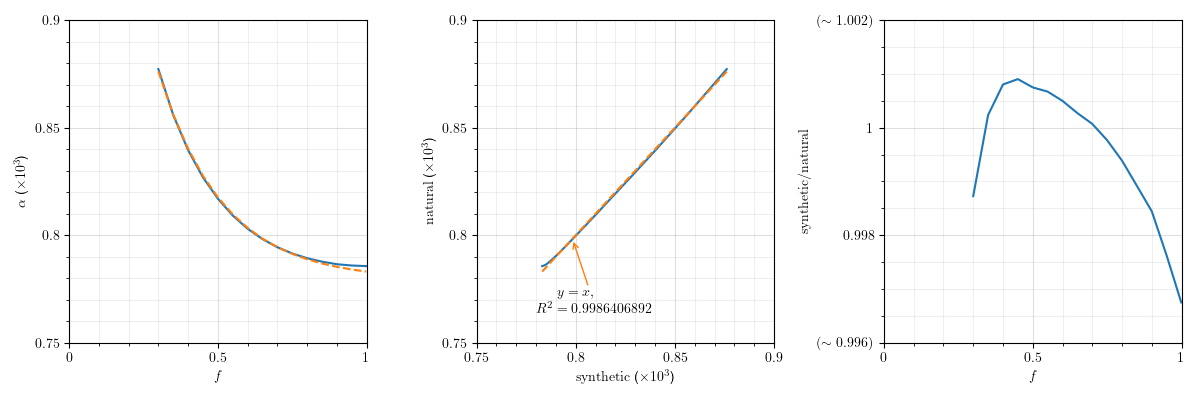

In [3]:
slc = isomixed.loc[0, 1]

canvas = Canvas(size=(12, 4), shape=(1, 3))

def model(x, /, a, b, c):
    return a * b**(x - c) + 8*math.pi**4
(*params,), error = curve_fit(model, slc.index, slc.values)
params = dict(zip('abc', (map(float, params))))
synthetic = model(slc.index, **params)
natural = slc.values
linscore = r2_score(synthetic, natural)

synth_colour = 'tab:orange'

ax1 = canvas.make_ax((0, 0))

xchan = Channel(
    slc.index, label=r"$f$",
    lims=(None, 1.), capped=(None, True),
    )
ax1.line(
    xchan,
    Channel(
        natural, label=r"$\alpha$",
        ),
    )
ax1.line(
    xchan,
    Channel(
        synthetic,
        ),
    color=synth_colour,
    linestyle='--',
    )

ax2 = canvas.make_ax((0, 1))

ax2.line(
    Channel(synthetic, label=r"$\mathrm{synthetic}$"),
    Channel(natural, label=r"$\mathrm{natural}$"),
    )

ax2.line(
    vals := np.linspace(np.min(synthetic), np.max(synthetic), 10), vals,
    color = synth_colour, linestyle = '--',
    )
ax2.annotate(
    *(map(np.median, (synthetic, natural))),
    label = f"${r'y=x, \\ R^2 =' + str(round(linscore, 10))}$",
    points = (15, -45),
    arrowprops = dict(arrowstyle = "->", color = synth_colour),
    )

ax3 = canvas.make_ax((0, 2))

ax3.line(
    xchan,
    Channel(
        synthetic / natural, label=r"$\mathrm{synthetic} / \mathrm{natural}$",
        )
    )


canvas

## Varying aspect ratio

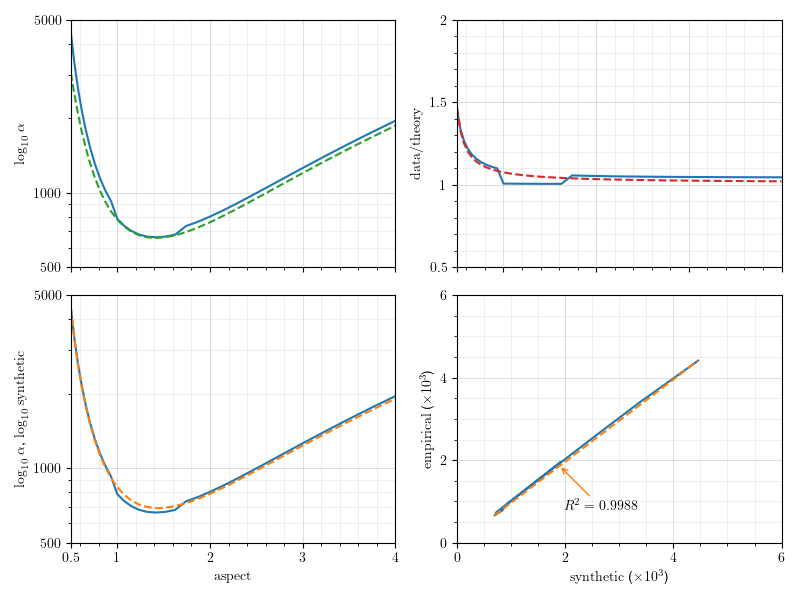

{'a': 0.09100267184029143,
 'b': 2.4004792841280476,
 'c': -0.4163101964000646,
 'd': 1.011269242812055}

In [4]:
slc = isomixed.loc[0, :, 0.999]

crit_func = lambda A: math.pi**4 * (1 + A**2)**3 / A**4
independent = slc.index
empirical = slc.values
theory = tuple(map(crit_func, slc.index))
discrepancy = empirical / theory

canvas = Canvas(size = (8, 6), shape = (2, 2))

synth_colour = 'tab:orange'

ax1 = canvas.ax((0, 0))
ax1.line(
    xchan := Channel(
        independent, label=r"$\mathrm{aspect}$",
        log=False, capped=(True, True),
        ),
    ychan := Channel(empirical, label=r"$\alpha$", log=True),
    )
ax1.line(
    xchan, Channel(theory, log=True),
    linestyle='--',
    color="tab:green"
    )

ax1.props.edges.x.label.visible = False
ax1.props.edges.x.ticks.major.labels = ()
# ax1.props.edges.x.swap()
# ax1.props.edges.x.ticks.major.labels[:] = []

def func(x, /, a, b, c, d):
    return a / (b*(x + c)) + d
(*params,), error = curve_fit(func, slc.index, discrepancy)
params = dict(zip('abcd', (map(float, params))))

correction = func(slc.index, **params)

ax2 = canvas.ax((0, 1))
ax2.line(
    xchan,
    Channel(discrepancy, label=r'$\mathrm{data} / \mathrm{theory}$'),
    )
ax2.line(
    xchan,
    Channel(correction),
    linestyle='--',
    color="tab:red",
    )

ax2.props.edges.x.label.visible = False
ax2.props.edges.x.ticks.major.labels = ()

synthetic = theory * correction

ax3 = canvas.ax((1, 0))
ax3.line(
    xchan,
    ychan,
    )
ax3.line(
    xchan,
    Channel(synthetic, label=r"$\mathrm{synthetic}$", log=True),
    linestyle='--',
    color=synth_colour,
    )

ax4 = canvas.ax((1, 1))
ax4.line(
    Channel(synthetic, label=r"$\mathrm{synthetic}$"),
    Channel(empirical, label=r"$\mathrm{empirical}$"),
    )
linscore = r2_score(synthetic, empirical)
ax4.line(
    Channel(np.linspace(min(synthetic), max(synthetic), 100)),
    Channel(np.linspace(min(empirical), max(empirical), 100)),
    linestyle = '--',
    )
ax4.annotate(
    (max(synthetic) - min(synthetic)) / 2,
    (max(empirical) - min(empirical)) / 2,
    label = f"${'R^2 =' + str(round(linscore, 5))}$",
    points = (30, -30),
    arrowprops = dict(arrowstyle = "->", color = synth_colour),
    )

display(canvas)
display(params)

## Varying heat input

In [3]:
isointernal

H           aspect  f    
0.025119    1.0     0.999    920.510582
0.031623    1.0     0.999    920.131684
0.039811    1.0     0.999    919.640187
0.050119    1.0     0.999    919.036283
0.063096    1.0     0.999    918.288051
                                ...    
125.892541  1.0     0.999    138.227092
158.489319  1.0     0.999    113.774222
199.526231  1.0     0.999     93.058366
251.188643  1.0     0.999     75.708306
316.227766  1.0     0.999     61.318436
Name: alpha, Length: 1075, dtype: float64

In [6]:
slc = isointernal.loc[:, 1., 0.999]

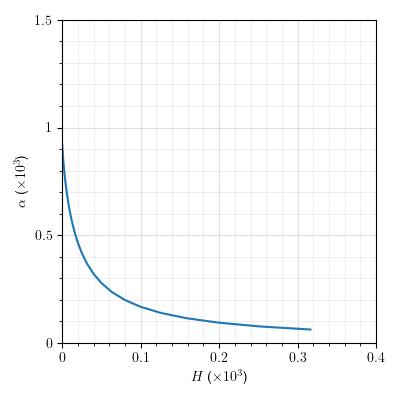

In [11]:
canvas = Canvas(size=(4, 4))

ax1 = canvas.make_ax()

ax1.line(
    Channel(slc.index, label='$H$'),
    Channel(slc.values, label=r'$\alpha$'),
    )

canvas

In [ ]:
round(len(synthetic) / 2)

In [ ]:
len(synthetic)

In [ ]:
synthetic